In [21]:
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mne_bids import BIDSPath
from scipy.ndimage import gaussian_filter1d

In [22]:
cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

# Fig 3: Time-resolved multivariate decoding

Publication figure for ROI-level high-gamma decoding accuracy across trial phases
(Stimulus → Delay → Go → Response). Matches `fig3_rt_legacy.ipynb` line-plot style.

Data: `../results/{task}(roi)(bipolar)/` resolved H5 outputs. Edit `hue_order` and
`FIGURE_SPECS` in the config cell below, then run the batch export cell (on a compute
node for full regeneration).

## Config

Edit `hue_order`, `hemi`, `description`, and `articulator_phoneme_filter` at the top of
the next cell. `FIGURE_SPECS` lists all task × decode-type combinations for batch export.
Each entry is `(task, decode_type)` or `(task, decode_type, description)`; omit the third
element to use the global `description` (default `Repeat`).

In [23]:
ref = 'bipolar'
phases = ['Stimulus', 'Delay', 'Go', 'Response']

# --- user-editable ROI / cohort filters ---
hue_order = ['AIC', 'PIC', 'SMC','STG']  # e.g. add 'STG'
hemi = 'Left'
description = 'Repeat'
articulator_phoneme_filter = '1'  # path.recording for articulator H5s; None = all phonemes

smooth_sigma = 2
results_root = Path('..') / 'results'
export_dir = Path('../img/fig3')

# All publication panels to generate.
# Each entry: (task, decode_type) or (task, decode_type, description).
FIGURE_SPECS = [
    ('LexicalDelay', 'lexicality'),
    ('LexicalDelay', 'lexicality', 'Decision'),
    ('LexicalDelay', 'phoneme'),
    ('LexicalDelay', 'articulator'),
    ('PhonemeSequence', 'phoneme'),
    ('PhonemeSequence', 'articulator'),
]


def parse_figure_spec(spec: tuple) -> tuple[str, str, str]:
    """Return (task, decode_type, description) from a FIGURE_SPECS entry."""
    if len(spec) == 2:
        task, decode_type = spec
        return task, decode_type, description
    if len(spec) == 3:
        task, decode_type, spec_description = spec
        return task, decode_type, spec_description
    raise ValueError(f'Invalid FIGURE_SPECS entry: {spec!r}')


def figure_output_name(task: str, decode_type: str, spec_description: str) -> str:
    """SVG basename; non-Repeat conditions get a suffix (e.g. _Decision)."""
    base = f'fig3_{task}_{decode_type}'
    if spec_description != 'Repeat':
        return f'{base}_{spec_description}.svg'
    return f'{base}.svg'

ROI_COLOR_MAP = {
    'AIC': red,
    'PIC': blue,
    'STG': stg_color,
    'SMC': 'black',
}


def roi_colors_for(rois: list[str]) -> list[str]:
    return [ROI_COLOR_MAP.get(roi, 'gray') for roi in rois]

## Load resolved decoding results

`load_resolved_decoding()` reads all matching H5 files and returns a long-format
DataFrame. Supports lexicality, phoneme, and articulator decode types. For articulator,
`path.recording` is stored in the `phoneme` column and filtered via
`articulator_phoneme_filter` (default `'1'`). Missing result directories or empty
matches return an empty DataFrame instead of raising.

`chance_level(decode_type, task)` returns `1 / n_classes` from pipeline defaults.

In [24]:
# Default n_classes from decoding pipeline / legacy fig3 notebooks.
# Keys are (decode_type, task); articulator assumes articulator_phoneme_filter='1'.
N_CLASSES = {
    ('phoneme', 'LexicalDelay'): 5,
    ('phoneme', 'PhonemeSequence'): 5,
    ('articulator', 'LexicalDelay'): 4,
    ('articulator', 'PhonemeSequence'): 4,
    ('lexicality', 'LexicalDelay'): 2,
}
_DECODE_TYPE_DEFAULT_N = {
    'phoneme': 5,
    'articulator': 4,
    'lexicality': 2,
}


def chance_level(decode_type: str, task: str) -> float:
    """Chance accuracy = 1 / n_classes for the decode type and task."""
    n = N_CLASSES.get((decode_type, task))
    if n is None:
        n = _DECODE_TYPE_DEFAULT_N.get(decode_type)
    if n is None:
        warnings.warn(f'Unknown decode_type={decode_type!r}; using n_classes=2')
        n = 2
    return 1.0 / n


def phase_accuracy_bar_params(decode_type: str, task: str) -> tuple[float, float]:
    """Significance-bar strip pad and bar height from legacy fig3 notebooks."""
    n = N_CLASSES.get((decode_type, task))
    if n is None:
        n = _DECODE_TYPE_DEFAULT_N.get(decode_type, 2)
    if decode_type == 'lexicality':
        return 0.01, 0.02
    if n >= 5:
        return 0.03, 0.02
    return 0.03, 0.01


def phase_accuracy_data_ylim(
    scores: pd.DataFrame,
    *,
    phases: list[str],
    hue_order: list[str],
    hemi: str,
    ymin_pad: float = 0.1,
    ymax_pad: float = 0.1,
) -> tuple[float, float]:
    """Data-driven ymin/ymax from accuracy values actually plotted."""
    subset = scores[
        scores['hemi'].eq(hemi)
        & scores['phase'].isin(phases)
        & scores['roi'].isin(hue_order)
    ]
    acc = subset['accuracy'].dropna()
    if acc.empty:
        raise ValueError('No accuracy values for y-axis limits.')
    ymin = max(0.0, float(acc.min()) - ymin_pad)
    ymax = float(acc.max()) + ymax_pad
    return ymin, ymax


SCORE_COLUMNS = [
    'time', 'fold', 'accuracy', 'baseline', 'p_value', 'mask',
    'roi', 'phase', 'hemi', 'description', 'phoneme', 'datatype', 'band',
]


def _empty_scores() -> pd.DataFrame:
    return pd.DataFrame(columns=SCORE_COLUMNS)


def _h5_to_long_df(path, smooth_sigma: float = 2) -> pd.DataFrame:
    with h5py.File(path, 'r') as mat:
        accuracy = mat['accuracy'][()]
        time = mat['time'][()]
        p_value = mat['p_values'][()]
        baseline = mat['baseline'][()]
        mask = mat['mask'][()] if 'mask' in mat else None

    n_time, n_fold = accuracy.shape
    baseline_mean = baseline.mean(axis=-1)

    accuracy = gaussian_filter1d(
        accuracy, sigma=smooth_sigma, axis=0, mode='nearest',
    )

    df_acc = pd.DataFrame(accuracy, index=time, columns=range(n_fold)).reset_index()
    df_acc = df_acc.rename(columns={'index': 'time'})

    df_base = pd.DataFrame(baseline_mean, index=time, columns=range(n_fold)).reset_index()
    df_base = df_base.rename(columns={'index': 'time'})

    df_acc = df_acc.melt(id_vars='time', var_name='fold', value_name='accuracy')
    df_base = df_base.melt(id_vars='time', var_name='fold', value_name='baseline')
    df = df_acc.merge(df_base, on=['time', 'fold'], how='left')

    df_p = pd.DataFrame({'time': time, 'p_value': p_value})
    if mask is not None:
        df_p['mask'] = mask.astype(bool)
    df = df.merge(df_p, on='time', how='left')

    hemi_label = 'Left' if path.subject.endswith('l') else 'Right'
    df['roi'] = path.subject[:-1]
    df['phase'] = path.processing
    df['hemi'] = hemi_label
    df['description'] = path.description
    df['phoneme'] = path.recording
    df['datatype'] = path.datatype
    df['band'] = path.suffix
    return df


def load_resolved_decoding(
    task: str,
    decode_type: str,
    *,
    ref: str = 'bipolar',
    rois=None,
    hemi: str | None = None,
    description: str | None = None,
    articulator_phoneme_filter: str | None = '1',
    smooth_sigma: float = 2,
    results_root=Path('..') / 'results',
) -> pd.DataFrame:
    """Load time-resolved decoding scores from resolved H5 outputs.

  Supports lexicality, phoneme, and articulator decode types. For articulator,
  ``path.recording`` is stored in the ``phoneme`` column (legacy pattern).

  Returns an empty DataFrame when the results directory is missing, no H5 files
  match, or every file is unreadable.
    """
    results_root = Path(results_root)
    root = results_root / f'{task}(roi)({ref})'
    if not root.exists():
        warnings.warn(f'Missing decoding results directory: {root}')
        return _empty_scores()

    result_path = BIDSPath(
        datatype=f'(decode)(resolved){decode_type}',
        root=str(root),
        suffix='highgamma',
        check=False,
    )
    paths = result_path.match()
    if not paths:
        warnings.warn(
            f'No resolved decoding H5 files for task={task}, decode_type={decode_type}'
        )
        return _empty_scores()

    frames = []
    for path in paths:
        try:
            frames.append(_h5_to_long_df(path, smooth_sigma=smooth_sigma))
        except OSError as exc:
            warnings.warn(f'Skipping unreadable file {path}: {exc}')

    if not frames:
        return _empty_scores()

    scores = pd.concat(frames, ignore_index=True)

    if description is not None:
        scores = scores[scores['description'] == description]

    if hemi is not None:
        scores = scores[scores['hemi'] == hemi]

    if rois is not None:
        scores = scores[scores['roi'].isin(rois)]

    if decode_type == 'articulator' and articulator_phoneme_filter is not None:
        scores = scores[scores['phoneme'] == articulator_phoneme_filter]

    return scores.reset_index(drop=True)

In [25]:
# Quick preview for one combination (edit task/decode_type as needed)
preview_task, preview_decode, preview_description = parse_figure_spec(FIGURE_SPECS[0])

scores = load_resolved_decoding(
    preview_task,
    preview_decode,
    ref=ref,
    rois=hue_order,
    hemi=hemi,
    description=preview_description,
    articulator_phoneme_filter=articulator_phoneme_filter,
    smooth_sigma=smooth_sigma,
    results_root=results_root,
)
print(
    f'Preview {preview_task}/{preview_decode}: {len(scores):,} rows | '
    f'ROIs: {sorted(scores.roi.unique()) if not scores.empty else []} | '
    f'chance={chance_level(preview_decode, preview_task):.3f}'
)
scores.head()

Preview LexicalDelay/lexicality: 4,640 rows | ROIs: ['AIC', 'PIC', 'SMC', 'STG'] | chance=0.500


,time,fold,accuracy,baseline,p_value,mask,roi,phase,hemi,description,phoneme,datatype,band
0,-0.20,0,0.488116,0.494559,0.552239,False,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma
1,-0.17,0,0.492379,0.498235,0.636816,False,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma
2,-0.14,0,0.494003,0.500294,0.393035,False,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma
3,-0.11,0,0.495477,0.497206,0.830846,False,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma
4,-0.08,0,0.501218,0.498382,0.706468,False,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma


## Four-phase accuracy line plot

One row of panels (Stimulus → Response) with ROI-colored accuracy traces. Significance
bars above each trace mark cluster-corrected `p < 0.01` time points (`fold == 1`, legacy).

In [26]:
from matplotlib.ticker import MaxNLocator


def plot_phase_accuracy(
    scores: pd.DataFrame,
    *,
    phases: list[str],
    hue_order: list[str],
    hemi: str = 'Left',
    chance: float | None = None,
    decode_type: str | None = None,
    task: str | None = None,
    roi_colors=None,
    xlim: tuple[float, float] = (-0.5, 1.0),
    ymax: float | None = None,
    ymin: float | None = None,
    pad: float | None = None,
    bar_h: float | None = None,
    sig_p: float = 0.01,
    sig_fold: int = 1,
    legend_panel: int | None = None,
    xlabel_panel: int | None = None,
):
    """Four-phase decoding accuracy figure (publication style, legacy fig3)."""
    if scores.empty:
        raise ValueError('No decoding scores to plot. Check results paths and parameters.')

    if chance is None:
        if decode_type is None or task is None:
            raise ValueError('Provide chance or both decode_type and task.')
        chance = chance_level(decode_type, task)
    if ymin is None or ymax is None:
        data_ymin, data_ymax = phase_accuracy_data_ylim(
            scores, phases=phases, hue_order=hue_order, hemi=hemi,
        )
        ymin = data_ymin if ymin is None else ymin
        ymax = data_ymax if ymax is None else ymax
    if pad is None or bar_h is None:
        if decode_type is None or task is None:
            raise ValueError('Provide pad/bar_h or both decode_type and task.')
        default_pad, default_bar_h = phase_accuracy_bar_params(decode_type, task)
        pad = default_pad if pad is None else pad
        bar_h = default_bar_h if bar_h is None else bar_h

    roi_colors = roi_colors or roi_colors_for(hue_order)
    n_phases = len(phases)
    legend_panel = n_phases // 2 if legend_panel is None else legend_panel
    xlabel_panel = n_phases // 2 if xlabel_panel is None else xlabel_panel
    y_top = ymax + pad + len(hue_order) * (bar_h + 0.005) + 0.02

    fig, axes = plt.subplots(1, n_phases, figsize=(2.5 * n_phases * cm, 3 * cm))
    if n_phases == 1:
        axes = [axes]

    plt.subplots_adjust(wspace=-0.1)

    for j, phase in enumerate(phases):
        ax = axes[j]
        subset = scores[(scores.phase == phase) & (scores.hemi == hemi)]

        sns.lineplot(
            data=subset,
            x='time', y='accuracy', hue='roi',
            palette=roi_colors, hue_order=hue_order,
            lw=1, ax=ax, legend=(j == legend_panel),
        )
        ax.set_autoscale_on(False)
        ax.margins(y=0)

        for k, roi in enumerate(hue_order):
            roi_data = subset[(subset.roi == roi) & (subset.fold == sig_fold)].sort_values('time')
            if roi_data.empty:
                continue
            if 'mask' in roi_data.columns and roi_data['mask'].notna().any():
                mask = roi_data['mask'].values.astype(bool)
            else:
                mask = roi_data['p_value'].values < sig_p
            offset = k * (bar_h + 0.005)
            if mask.any():
                ax.fill_between(
                    roi_data['time'].values,
                    ymax + pad + offset,
                    ymax + pad + bar_h + offset,
                    where=mask,
                    color=roi_colors[k],
                    alpha=1,
                    step='mid',
                    linewidth=0,
                )

    for j, phase in enumerate(phases):
        ax = axes[j]
        ax.tick_params(labelsize=fontsize, width=0.5, length=2)
        plt.setp(ax.spines.values(), linewidth=0.75)
        ax.axvline(x=0, color='gray', linestyle='--', lw=0.5)
        ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
        ax.set_xlim(*xlim)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(phase.capitalize(), fontsize=fontsize)

        if j == 0:
            ax.set_ylabel('Accuracy', fontsize=fontsize)

    axes[xlabel_panel].set_xlabel('Time (s)', fontsize=fontsize)
    if axes[legend_panel].get_legend() is not None:
        axes[legend_panel].legend(fontsize=fontsize)

    for ax in axes:
        sns.despine(ax=ax, trim=True, offset=0.1)

    for ax in axes[1:]:
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.set_ylabel('')

    axes[0].yaxis.set_tick_params(labelleft=True)
    axes[0].yaxis.set_visible(True)

    for ax in axes:
        ax.set_ylim(ymin, y_top)
        ax.set_ybound(ymin, y_top)

    axes[0].yaxis.set_major_locator(MaxNLocator(nbins=3))

    return fig, axes

Preview ylim expected=(0.065, 1.006) got=(0.065, 1.006) ticks=[0.  0.4 0.8 1.2]


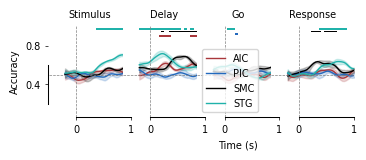

In [27]:
# Preview plot for the first FIGURE_SPECS entry
if scores.empty:
    print('Skipping preview plot: no decoding data loaded.')
else:
    preview_ymin, preview_ymax = phase_accuracy_data_ylim(
        scores, phases=phases, hue_order=hue_order, hemi=hemi,
    )
    preview_pad, preview_bar_h = phase_accuracy_bar_params(preview_decode, preview_task)
    preview_y_top = (
        preview_ymax + preview_pad
        + len(hue_order) * (preview_bar_h + 0.005) + 0.02
    )
    fig, axes = plot_phase_accuracy(
        scores,
        phases=phases,
        hue_order=hue_order,
        hemi=hemi,
        decode_type=preview_decode,
        task=preview_task,
        roi_colors=roi_colors_for(hue_order),
        ymin=preview_ymin,
        ymax=preview_ymax,
    )
    got = axes[0].get_ylim()
    print(
        f'Preview ylim expected=({preview_ymin:.3f}, {preview_y_top:.3f}) '
        f'got=({got[0]:.3f}, {got[1]:.3f}) ticks={axes[0].get_yticks().round(3)}'
    )
    plt.show()

## Batch export

Run on a compute node. Writes `../img/fig3/fig3_{task}_{decode_type}.svg` (Repeat) or
`fig3_{task}_{decode_type}_{description}.svg` (other conditions) for every entry in
`FIGURE_SPECS`.

Saved ../img/fig3/fig3_LexicalDelay_lexicality.svg (chance=0.500, ylim=(0.06, 1.01), n=4,640)
Saved ../img/fig3/fig3_LexicalDelay_lexicality_Decision.svg (chance=0.500, ylim=(0.07, 1.10), n=4,640)
Saved ../img/fig3/fig3_LexicalDelay_phoneme.svg (chance=0.200, ylim=(0.00, 0.48), n=4,640)
Skip fig3_LexicalDelay_articulator.svg: no decoding data loaded.
Saved ../img/fig3/fig3_PhonemeSequence_phoneme.svg (chance=0.200, ylim=(0.00, 0.64), n=4,640)
Saved ../img/fig3/fig3_PhonemeSequence_articulator.svg (chance=0.250, ylim=(0.00, 0.87), n=4,640)


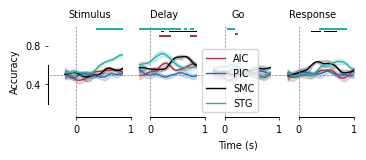

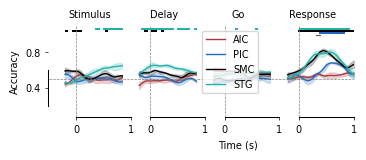

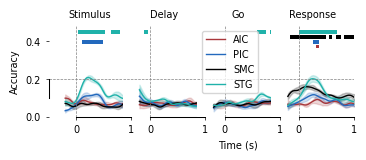

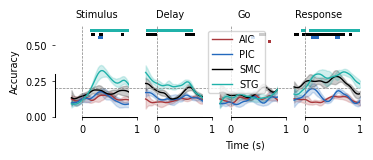

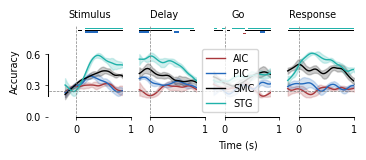

In [28]:
export_dir.mkdir(parents=True, exist_ok=True)

for spec in FIGURE_SPECS:
    task, decode_type, spec_description = parse_figure_spec(spec)
    scores = load_resolved_decoding(
        task,
        decode_type,
        ref=ref,
        rois=hue_order,
        hemi=hemi,
        description=spec_description,
        articulator_phoneme_filter=articulator_phoneme_filter,
        smooth_sigma=smooth_sigma,
        results_root=results_root,
    )
    out_path = export_dir / figure_output_name(task, decode_type, spec_description)

    if scores.empty:
        print(f'Skip {out_path.name}: no decoding data loaded.')
        continue

    chance = chance_level(decode_type, task)
    ymin, ymax = phase_accuracy_data_ylim(
        scores, phases=phases, hue_order=hue_order, hemi=hemi,
    )
    pad, bar_h = phase_accuracy_bar_params(decode_type, task)
    y_top = ymax + pad + len(hue_order) * (bar_h + 0.005) + 0.02
    fig, _ = plot_phase_accuracy(
        scores,
        phases=phases,
        hue_order=hue_order,
        hemi=hemi,
        decode_type=decode_type,
        task=task,
        roi_colors=roi_colors_for(hue_order),
        ymin=ymin,
        ymax=ymax,
    )
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved {out_path} (chance={chance:.3f}, ylim=({ymin:.2f}, {y_top:.2f}), n={len(scores):,})')